In [1]:
# ============================================================
# PHASE 22 — EARLY FUSION VS LATE FUSION VS STACKING
# ============================================================
# Goal:
# Test whether multimodal integration improves when modalities are
# combined at the decision level rather than only by feature concatenation.
#
# Compared strategies:
# 1. Single-modality baselines
#    - Protein-only
#    - Handcrafted genomic-only
#    - DNABERT-2 genomic-only
#
# 2. Early fusion
#    - Protein + handcrafted genomic concatenation
#    - Protein + DNABERT-2 genomic concatenation
#
# 3. Late fusion
#    - Weighted average of protein and genomic prediction scores
#
# 4. Stacking
#    - Logistic regression meta-classifier using modality-level scores
#
# Outputs:
# - repeated CV metrics
# - paired comparisons
# - best fusion strategy by PR-AUC/MCC
# - fusion weight analysis
# - manuscript-ready tables and figures
# ============================================================

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    matthews_corrcoef,
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix
)
from scipy.stats import wilcoxon, binomtest
from statsmodels.stats.multitest import multipletests

pd.set_option("display.max_columns", 250)
pd.set_option("display.max_colwidth", 400)

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

import os
from pathlib import Path
import pandas as pd
from google.colab import drive

try:
    drive.mount('/content/drive')
except ValueError:
    print("Drive đã được kết nối từ trước.")

PROJECT_DIR = Path("/content/drive/MyDrive/Project_Protein")

PHASE3_DIR = PROJECT_DIR / "model" / "phase3_multimodal_integration"
SHARED_DIR = PHASE3_DIR / "shared_dataset"

PHASE22_DIR = PROJECT_DIR / "model" / "phase22_multimodal_fusion_strategy_comparison"
RESULT_DIR = PHASE22_DIR / "results"
FIGURE_DIR = PHASE22_DIR / "figures"
EXCEL_DIR = PHASE22_DIR / "excel"
REPORT_DIR = PHASE22_DIR / "reports"

for d in [PHASE22_DIR, RESULT_DIR, FIGURE_DIR, EXCEL_DIR, REPORT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Phase 22 output:", PHASE22_DIR)

Mounted at /content/drive
Phase 22 output: /content/drive/MyDrive/Project_Protein/model/phase22_multimodal_fusion_strategy_comparison


In [2]:
# ============================================================
# HELPER FUNCTIONS
# ============================================================

def load_npy_required(path):
    path = Path(path)
    assert path.exists(), f"Missing required file: {path}"
    arr = np.load(path, allow_pickle=True)
    print("Loaded:", path, arr.shape)
    return arr


def save_df(df, path):
    path = Path(path)
    df.to_csv(path, index=False)
    print("Saved:", path)


def round_numeric_columns(df, digits=5):
    df = df.copy()
    for col in df.columns:
        if pd.api.types.is_float_dtype(df[col]):
            df[col] = df[col].round(digits)
    return df


def choose_threshold_by_mcc(y_true, y_score, n_grid=501):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score)

    thresholds = np.unique(np.quantile(y_score, np.linspace(0, 1, n_grid)))

    best_thr = float(thresholds[0])
    best_mcc = -999

    for thr in thresholds:
        pred = (y_score >= thr).astype(int)
        mcc = matthews_corrcoef(y_true, pred)

        if mcc > best_mcc:
            best_mcc = mcc
            best_thr = float(thr)

    return best_thr, float(best_mcc)


def evaluate_prediction(y_true, y_score, threshold):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score)
    y_pred = (y_score >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    return {
        "roc_auc": roc_auc_score(y_true, y_score),
        "pr_auc": average_precision_score(y_true, y_score),
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "specificity": tn / (tn + fp) if (tn + fp) > 0 else np.nan,
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "mcc": matthews_corrcoef(y_true, y_pred),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "threshold": float(threshold)
    }


def get_scores(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, "decision_function"):
        s = model.decision_function(X)
        return 1 / (1 + np.exp(-s))
    return model.predict(X)


def build_svm(seed=42):
    return Pipeline([
        ("variance", VarianceThreshold()),
        ("scaler", StandardScaler()),
        ("model", SVC(
            C=1.0,
            gamma="scale",
            kernel="rbf",
            probability=True,
            class_weight="balanced",
            random_state=seed
        ))
    ])


def build_rf(seed=42):
    return Pipeline([
        ("variance", VarianceThreshold()),
        ("model", RandomForestClassifier(
            n_estimators=500,
            max_depth=10,
            min_samples_leaf=5,
            max_features="sqrt",
            class_weight="balanced",
            random_state=seed,
            n_jobs=-1
        ))
    ])


def build_lr_meta(seed=42):
    return LogisticRegression(
        C=1.0,
        penalty="l2",
        solver="liblinear",
        class_weight="balanced",
        random_state=seed,
        max_iter=5000
    )


def bootstrap_ci_mean(values, n_boot=3000, seed=42, ci=95):
    rng_local = np.random.default_rng(seed)
    values = np.asarray(values, dtype=float)

    boots = []
    for _ in range(n_boot):
        boots.append(np.mean(rng_local.choice(values, size=len(values), replace=True)))

    alpha = (100 - ci) / 2
    return (
        float(np.percentile(boots, alpha)),
        float(np.percentile(boots, 100 - alpha))
    )


def paired_test_table(df, model_a, model_b, metrics):
    records = []

    for metric in metrics:
        a = df[df["fusion_model"] == model_a].sort_values("split_id")[metric].values
        b = df[df["fusion_model"] == model_b].sort_values("split_id")[metric].values

        if len(a) != len(b) or len(a) == 0:
            continue

        delta = a - b

        try:
            p_w = wilcoxon(delta).pvalue
        except Exception:
            p_w = np.nan

        wins = int(np.sum(delta > 0))
        losses = int(np.sum(delta < 0))
        ties = int(np.sum(delta == 0))

        try:
            p_sign = binomtest(wins, wins + losses, 0.5).pvalue if (wins + losses) > 0 else np.nan
        except Exception:
            p_sign = np.nan

        ci_low, ci_high = bootstrap_ci_mean(delta, seed=RANDOM_SEED)

        records.append({
            "comparison": f"{model_a} minus {model_b}",
            "model_a": model_a,
            "model_b": model_b,
            "metric": metric,
            "mean_delta": np.mean(delta),
            "sd_delta": np.std(delta, ddof=1),
            "ci95_low": ci_low,
            "ci95_high": ci_high,
            "wins_model_a": wins,
            "wins_model_b": losses,
            "ties": ties,
            "wilcoxon_p": p_w,
            "sign_test_p": p_sign,
            "n_pairs": len(delta)
        })

    out = pd.DataFrame(records)

    if not out.empty:
        valid = out["wilcoxon_p"].notna()
        out["wilcoxon_bh_fdr"] = np.nan
        if valid.sum() > 0:
            out.loc[valid, "wilcoxon_bh_fdr"] = multipletests(
                out.loc[valid, "wilcoxon_p"],
                method="fdr_bh"
            )[1]

    return out

In [3]:
# ============================================================
# LOAD SHARED FEATURE ARRAYS
# ============================================================
SHARED_DIR = PHASE3_DIR / "features"
PHASE5_DIR1 = PROJECT_DIR / "model" / "phase5_dnabert2_genomic_foundation"
SHARED_DIR1 = PHASE5_DIR1 / "embeddings"
SHARED_DIR2 = PHASE3_DIR / "shared_dataset"

# Protein
X_train_protein = load_npy_required(SHARED_DIR / "X_train_protein_protbert_sw_v1.npy")
X_val_protein   = load_npy_required(SHARED_DIR / "X_val_protein_protbert_sw_v1.npy")
X_test_protein  = load_npy_required(SHARED_DIR / "X_test_protein_protbert_sw_v1.npy")

# Handcrafted multimodal: ProtBERT + K3/K4/Basic
X_train_hand = load_npy_required(SHARED_DIR / "X_train_combined_protein_genomic_v1.npy")
X_val_hand   = load_npy_required(SHARED_DIR / "X_val_combined_protein_genomic_v1.npy")
X_test_hand  = load_npy_required(SHARED_DIR / "X_test_combined_protein_genomic_v1.npy")

# DNABERT-2 multimodal: ProtBERT + DNABERT-2
X_train_dna = load_npy_required(SHARED_DIR1 / "X_train_combined_protbert_sw_dnabert2_v1.npy")
X_val_dna   = load_npy_required(SHARED_DIR1 / "X_val_combined_protbert_sw_dnabert2_v1.npy")
X_test_dna  = load_npy_required(SHARED_DIR1 / "X_test_combined_protbert_sw_dnabert2_v1.npy")

# Labels
y_train = load_npy_required(SHARED_DIR2 / "y_train_multimodal_v1.npy").astype(int)
y_val   = load_npy_required(SHARED_DIR2 / "y_val_multimodal_v1.npy").astype(int)
y_test  = load_npy_required(SHARED_DIR2 / "y_test_multimodal_v1.npy").astype(int)

# Combine old train + val + test into one full shared dataset
X_protein_full = np.vstack([X_train_protein, X_val_protein, X_test_protein])
X_hand_full = np.vstack([X_train_hand, X_val_hand, X_test_hand])
X_dna_full = np.vstack([X_train_dna, X_val_dna, X_test_dna])
y_full = np.concatenate([y_train, y_val, y_test]).astype(int)

PROTEIN_DIM = 1024

X_genomic_hand_full = X_hand_full[:, PROTEIN_DIM:]
X_genomic_dna_full = X_dna_full[:, PROTEIN_DIM:]

print("Full feature shapes:")
print("Protein:", X_protein_full.shape)
print("Handcrafted genomic:", X_genomic_hand_full.shape)
print("DNABERT-2 genomic:", X_genomic_dna_full.shape)
print("Early handcrafted multimodal:", X_hand_full.shape)
print("Early DNABERT-2 multimodal:", X_dna_full.shape)
print("Labels:", y_full.shape, np.bincount(y_full))

Loaded: /content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/features/X_train_protein_protbert_sw_v1.npy (1264, 1024)
Loaded: /content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/features/X_val_protein_protbert_sw_v1.npy (271, 1024)
Loaded: /content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/features/X_test_protein_protbert_sw_v1.npy (271, 1024)
Loaded: /content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/features/X_train_combined_protein_genomic_v1.npy (1264, 1380)
Loaded: /content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/features/X_val_combined_protein_genomic_v1.npy (271, 1380)
Loaded: /content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/features/X_test_combined_protein_genomic_v1.npy (271, 1380)
Loaded: /content/drive/MyDrive/Project_Protein/model/phase5_dnabert2_genomic_foundation/embeddings/X_train_combined_protbert_sw_dnabert2_v1.npy (1264, 1792

In [4]:
# ============================================================
# EVALUATION SETTINGS
# ============================================================

N_SPLITS = 5
N_REPEATS = 3

# Increase to 5 repeats if runtime is acceptable.
# 3 repeats x 5 folds = 15 paired evaluations.

WEIGHT_GRID = np.linspace(0, 1, 21)
# w = protein weight
# combined_score = w * protein_score + (1 - w) * genomic_score

metrics_main = ["pr_auc", "mcc", "roc_auc", "f1"]

cv = RepeatedStratifiedKFold(
    n_splits=N_SPLITS,
    n_repeats=N_REPEATS,
    random_state=RANDOM_SEED
)

print("Repeated CV:", N_REPEATS, "x", N_SPLITS, "=", N_REPEATS * N_SPLITS)

Repeated CV: 3 x 5 = 15


In [5]:
# ============================================================
# RUN FUSION STRATEGY COMPARISON
# ============================================================

records = []
prediction_records = []
fusion_weight_records = []

split_id = 0

for train_val_idx, test_idx in cv.split(X_protein_full, y_full):
    split_id += 1

    print("=" * 120)
    print(f"Split {split_id}/{N_SPLITS * N_REPEATS}")

    y_train_val = y_full[train_val_idx]
    y_test_fold = y_full[test_idx]

    # Inner validation split
    inner_cv = RepeatedStratifiedKFold(
        n_splits=5,
        n_repeats=1,
        random_state=RANDOM_SEED + split_id
    )

    inner_train_rel, inner_val_rel = next(
        inner_cv.split(np.zeros(len(train_val_idx)), y_train_val)
    )

    train_idx = train_val_idx[inner_train_rel]
    val_idx = train_val_idx[inner_val_rel]

    y_train_fold = y_full[train_idx]
    y_val_fold = y_full[val_idx]

    # -------------------------
    # Train base modality models
    # -------------------------

    protein_model = build_svm(seed=RANDOM_SEED + split_id)
    hand_genomic_model = build_rf(seed=RANDOM_SEED + split_id)
    dna_genomic_model = build_svm(seed=RANDOM_SEED + split_id)

    protein_model.fit(X_protein_full[train_idx], y_train_fold)
    hand_genomic_model.fit(X_genomic_hand_full[train_idx], y_train_fold)
    dna_genomic_model.fit(X_genomic_dna_full[train_idx], y_train_fold)

    # Base scores
    protein_val_score = get_scores(protein_model, X_protein_full[val_idx])
    protein_test_score = get_scores(protein_model, X_protein_full[test_idx])

    hand_genomic_val_score = get_scores(hand_genomic_model, X_genomic_hand_full[val_idx])
    hand_genomic_test_score = get_scores(hand_genomic_model, X_genomic_hand_full[test_idx])

    dna_genomic_val_score = get_scores(dna_genomic_model, X_genomic_dna_full[val_idx])
    dna_genomic_test_score = get_scores(dna_genomic_model, X_genomic_dna_full[test_idx])

    # -------------------------
    # Single modality baselines
    # -------------------------

    single_models = {
        "Protein_only": {
            "score_val": protein_val_score,
            "score_test": protein_test_score,
            "fusion_type": "single_modality"
        },
        "Handcrafted_genomic_only": {
            "score_val": hand_genomic_val_score,
            "score_test": hand_genomic_test_score,
            "fusion_type": "single_modality"
        },
        "DNABERT2_genomic_only": {
            "score_val": dna_genomic_val_score,
            "score_test": dna_genomic_test_score,
            "fusion_type": "single_modality"
        }
    }

    for fusion_model, info in single_models.items():
        threshold, val_mcc = choose_threshold_by_mcc(y_val_fold, info["score_val"])
        metrics = evaluate_prediction(y_test_fold, info["score_test"], threshold)

        records.append({
            "split_id": split_id,
            "fusion_model": fusion_model,
            "fusion_type": info["fusion_type"],
            "n_train": len(train_idx),
            "n_val": len(val_idx),
            "n_test": len(test_idx),
            "validation_mcc": val_mcc,
            "selected_weight_protein": np.nan,
            "selected_weight_genomic": np.nan,
            **metrics
        })

    # -------------------------
    # Early fusion models
    # -------------------------

    early_hand_model = build_svm(seed=RANDOM_SEED + split_id)
    early_dna_model = build_svm(seed=RANDOM_SEED + split_id)

    early_hand_model.fit(X_hand_full[train_idx], y_train_fold)
    early_dna_model.fit(X_dna_full[train_idx], y_train_fold)

    early_hand_val_score = get_scores(early_hand_model, X_hand_full[val_idx])
    early_hand_test_score = get_scores(early_hand_model, X_hand_full[test_idx])

    early_dna_val_score = get_scores(early_dna_model, X_dna_full[val_idx])
    early_dna_test_score = get_scores(early_dna_model, X_dna_full[test_idx])

    early_models = {
        "Early_fusion_Protein_HandcraftedGenomic": {
            "score_val": early_hand_val_score,
            "score_test": early_hand_test_score
        },
        "Early_fusion_Protein_DNABERT2Genomic": {
            "score_val": early_dna_val_score,
            "score_test": early_dna_test_score
        }
    }

    for fusion_model, info in early_models.items():
        threshold, val_mcc = choose_threshold_by_mcc(y_val_fold, info["score_val"])
        metrics = evaluate_prediction(y_test_fold, info["score_test"], threshold)

        records.append({
            "split_id": split_id,
            "fusion_model": fusion_model,
            "fusion_type": "early_fusion",
            "n_train": len(train_idx),
            "n_val": len(val_idx),
            "n_test": len(test_idx),
            "validation_mcc": val_mcc,
            "selected_weight_protein": np.nan,
            "selected_weight_genomic": np.nan,
            **metrics
        })

    # -------------------------
    # Late fusion: weighted average
    # -------------------------

    late_fusion_specs = {
        "Late_fusion_Protein_HandcraftedGenomic": {
            "genomic_val": hand_genomic_val_score,
            "genomic_test": hand_genomic_test_score,
            "genomic_name": "Handcrafted_genomic"
        },
        "Late_fusion_Protein_DNABERT2Genomic": {
            "genomic_val": dna_genomic_val_score,
            "genomic_test": dna_genomic_test_score,
            "genomic_name": "DNABERT2_genomic"
        }
    }

    for fusion_model, info in late_fusion_specs.items():
        best_w = None
        best_val_mcc = -999
        best_val_score = None

        for w in WEIGHT_GRID:
            val_score = w * protein_val_score + (1 - w) * info["genomic_val"]
            threshold, val_mcc = choose_threshold_by_mcc(y_val_fold, val_score)

            if val_mcc > best_val_mcc:
                best_val_mcc = val_mcc
                best_w = float(w)
                best_threshold = threshold
                best_val_score = val_score

        test_score = best_w * protein_test_score + (1 - best_w) * info["genomic_test"]
        metrics = evaluate_prediction(y_test_fold, test_score, best_threshold)

        records.append({
            "split_id": split_id,
            "fusion_model": fusion_model,
            "fusion_type": "late_fusion_weighted_average",
            "n_train": len(train_idx),
            "n_val": len(val_idx),
            "n_test": len(test_idx),
            "validation_mcc": best_val_mcc,
            "selected_weight_protein": best_w,
            "selected_weight_genomic": 1 - best_w,
            **metrics
        })

        fusion_weight_records.append({
            "split_id": split_id,
            "fusion_model": fusion_model,
            "fusion_type": "late_fusion_weighted_average",
            "selected_weight_protein": best_w,
            "selected_weight_genomic": 1 - best_w,
            "validation_mcc": best_val_mcc
        })

    # -------------------------
    # Stacking meta-classifiers
    # -------------------------

    stacking_specs = {
        "Stacking_Protein_HandcraftedGenomic": {
            "val_matrix": np.column_stack([protein_val_score, hand_genomic_val_score]),
            "test_matrix": np.column_stack([protein_test_score, hand_genomic_test_score]),
            "feature_names": "protein_score; handcrafted_genomic_score"
        },
        "Stacking_Protein_DNABERT2Genomic": {
            "val_matrix": np.column_stack([protein_val_score, dna_genomic_val_score]),
            "test_matrix": np.column_stack([protein_test_score, dna_genomic_test_score]),
            "feature_names": "protein_score; dnabert2_genomic_score"
        },
        "Stacking_Protein_Handcrafted_DNABERT2": {
            "val_matrix": np.column_stack([protein_val_score, hand_genomic_val_score, dna_genomic_val_score]),
            "test_matrix": np.column_stack([protein_test_score, hand_genomic_test_score, dna_genomic_test_score]),
            "feature_names": "protein_score; handcrafted_genomic_score; dnabert2_genomic_score"
        }
    }

    for fusion_model, info in stacking_specs.items():
        meta_model = build_lr_meta(seed=RANDOM_SEED + split_id)
        meta_model.fit(info["val_matrix"], y_val_fold)

        val_stack_score = meta_model.predict_proba(info["val_matrix"])[:, 1]
        test_stack_score = meta_model.predict_proba(info["test_matrix"])[:, 1]

        threshold, val_mcc = choose_threshold_by_mcc(y_val_fold, val_stack_score)
        metrics = evaluate_prediction(y_test_fold, test_stack_score, threshold)

        records.append({
            "split_id": split_id,
            "fusion_model": fusion_model,
            "fusion_type": "stacking",
            "n_train": len(train_idx),
            "n_val": len(val_idx),
            "n_test": len(test_idx),
            "validation_mcc": val_mcc,
            "selected_weight_protein": np.nan,
            "selected_weight_genomic": np.nan,
            "meta_feature_names": info["feature_names"],
            **metrics
        })

phase22_results_df = pd.DataFrame(records)
phase22_weights_df = pd.DataFrame(fusion_weight_records)

phase22_results_df = round_numeric_columns(phase22_results_df, 5)
phase22_weights_df = round_numeric_columns(phase22_weights_df, 5)

display(phase22_results_df.head())
display(phase22_results_df.groupby("fusion_model").size())

save_df(phase22_results_df, RESULT_DIR / "phase22_all_fusion_strategy_fold_metrics.csv")
save_df(phase22_weights_df, RESULT_DIR / "phase22_late_fusion_selected_weights.csv")

Split 1/15
Split 2/15
Split 3/15
Split 4/15
Split 5/15
Split 6/15
Split 7/15
Split 8/15
Split 9/15
Split 10/15
Split 11/15
Split 12/15
Split 13/15
Split 14/15
Split 15/15


,split_id,fusion_model,fusion_type,n_train,n_val,n_test,validation_mcc,selected_weight_protein,selected_weight_genomic,roc_auc,pr_auc,accuracy,precision,recall,specificity,f1,mcc,tn,fp,fn,tp,threshold,meta_feature_names
0,1,Protein_only,single_modality,1155,289,362,0.31741,NaN,NaN,0.72754,0.70898,0.66022,0.71642,0.53039,0.79006,0.60952,0.33182,143,38,85,96,0.60258,NaN
1,1,Handcrafted_genomic_only,single_modality,1155,289,362,0.21735,NaN,NaN,0.62013,0.65338,0.58011,0.68354,0.29834,0.86188,0.41538,0.19395,156,25,127,54,0.58044,NaN
2,1,DNABERT2_genomic_only,single_modality,1155,289,362,0.25120,NaN,NaN,0.67208,0.66905,0.59945,0.57031,0.80663,0.39227,0.66819,0.21854,71,110,35,146,0.39681,NaN
3,1,Early_fusion_Protein_HandcraftedGenomic,early_fusion,1155,289,362,0.32242,NaN,NaN,0.74258,0.72489,0.69613,0.69613,0.69613,0.69613,0.69613,0.39227,126,55,55,126,0.51368,NaN
4,1,Early_fusion_Protein_DNABERT2Genomic,early_fusion,1155,289,362,0.37537,NaN,NaN,0.75312,0.74296,0.68785,0.77869,0.52486,0.85083,0.62706,0.39740,154,27,86,95,0.61321,NaN


,0
fusion_model,
DNABERT2_genomic_only,15
Early_fusion_Protein_DNABERT2Genomic,15
Early_fusion_Protein_HandcraftedGenomic,15
Handcrafted_genomic_only,15
Late_fusion_Protein_DNABERT2Genomic,15
Late_fusion_Protein_HandcraftedGenomic,15
Protein_only,15
Stacking_Protein_DNABERT2Genomic,15
Stacking_Protein_HandcraftedGenomic,15


Saved: /content/drive/MyDrive/Project_Protein/model/phase22_multimodal_fusion_strategy_comparison/results/phase22_all_fusion_strategy_fold_metrics.csv
Saved: /content/drive/MyDrive/Project_Protein/model/phase22_multimodal_fusion_strategy_comparison/results/phase22_late_fusion_selected_weights.csv


In [6]:
# ============================================================
# SUMMARY TABLE
# ============================================================

summary_records = []

metrics = ["pr_auc", "roc_auc", "mcc", "f1", "accuracy", "precision", "recall", "specificity"]

for fusion_model, sub in phase22_results_df.groupby("fusion_model"):
    for metric in metrics:
        vals = sub[metric].astype(float).values
        ci_low, ci_high = bootstrap_ci_mean(vals, seed=RANDOM_SEED)

        summary_records.append({
            "fusion_model": fusion_model,
            "fusion_type": sub["fusion_type"].iloc[0],
            "metric": metric,
            "mean": np.mean(vals),
            "sd": np.std(vals, ddof=1),
            "ci95_low": ci_low,
            "ci95_high": ci_high,
            "n_folds": len(vals)
        })

phase22_summary_long_df = pd.DataFrame(summary_records)
phase22_summary_long_df = round_numeric_columns(phase22_summary_long_df, 5)

display(phase22_summary_long_df.head(30))

save_df(phase22_summary_long_df, RESULT_DIR / "phase22_fusion_strategy_summary_long.csv")

# Wide table for main manuscript
main_metrics = ["pr_auc", "mcc", "roc_auc", "f1"]

wide_records = []

for fusion_model, sub in phase22_results_df.groupby("fusion_model"):
    rec = {
        "fusion_model": fusion_model,
        "fusion_type": sub["fusion_type"].iloc[0]
    }

    for metric in main_metrics:
        vals = sub[metric].astype(float).values
        rec[f"{metric}_mean"] = np.mean(vals)
        rec[f"{metric}_sd"] = np.std(vals, ddof=1)

    wide_records.append(rec)

phase22_summary_wide_df = pd.DataFrame(wide_records)

phase22_summary_wide_df = phase22_summary_wide_df.sort_values(
    ["pr_auc_mean", "mcc_mean"],
    ascending=False
).reset_index(drop=True)

phase22_summary_wide_df = round_numeric_columns(phase22_summary_wide_df, 5)

display(phase22_summary_wide_df)

save_df(phase22_summary_wide_df, RESULT_DIR / "phase22_fusion_strategy_summary_wide.csv")

,fusion_model,fusion_type,metric,mean,sd,ci95_low,ci95_high,n_folds
0,DNABERT2_genomic_only,single_modality,pr_auc,0.65065,0.03329,0.63440,0.66686,15
1,DNABERT2_genomic_only,single_modality,roc_auc,0.65827,0.02759,0.64458,0.67170,15
2,DNABERT2_genomic_only,single_modality,mcc,0.23668,0.04613,0.21531,0.25997,15
3,DNABERT2_genomic_only,single_modality,f1,0.54607,0.07070,0.51090,0.58123,15
4,DNABERT2_genomic_only,single_modality,accuracy,0.60982,0.02211,0.59978,0.62076,15
5,DNABERT2_genomic_only,single_modality,precision,0.66207,0.05799,0.63415,0.68912,15
6,DNABERT2_genomic_only,single_modality,recall,0.48768,0.13965,0.42310,0.56161,15
7,DNABERT2_genomic_only,single_modality,specificity,0.73212,0.14265,0.65615,0.79572,15
8,Early_fusion_Protein_DNABERT2Genomic,early_fusion,pr_auc,0.71577,0.02066,0.70598,0.72531,15
9,Early_fusion_Protein_DNABERT2Genomic,early_fusion,roc_auc,0.73203,0.02132,0.72196,0.74216,15


Saved: /content/drive/MyDrive/Project_Protein/model/phase22_multimodal_fusion_strategy_comparison/results/phase22_fusion_strategy_summary_long.csv


,fusion_model,fusion_type,pr_auc_mean,pr_auc_sd,mcc_mean,mcc_sd,roc_auc_mean,roc_auc_sd,f1_mean,f1_sd
0,Stacking_Protein_Handcrafted_DNABERT2,stacking,0.72101,0.01961,0.33056,0.04055,0.73344,0.01846,0.64623,0.06642
1,Stacking_Protein_DNABERT2Genomic,stacking,0.71929,0.02029,0.32848,0.03928,0.73168,0.01889,0.64277,0.06757
2,Late_fusion_Protein_DNABERT2Genomic,late_fusion_weighted_average,0.71738,0.02585,0.32684,0.04166,0.73070,0.02065,0.64877,0.05915
3,Early_fusion_Protein_DNABERT2Genomic,early_fusion,0.71577,0.02066,0.33877,0.05364,0.73203,0.02132,0.65015,0.06249
4,Early_fusion_Protein_HandcraftedGenomic,early_fusion,0.71449,0.01471,0.31894,0.04423,0.72548,0.01945,0.63650,0.04630
5,Late_fusion_Protein_HandcraftedGenomic,late_fusion_weighted_average,0.71312,0.02117,0.32047,0.04469,0.72541,0.02048,0.63504,0.05270
6,Stacking_Protein_HandcraftedGenomic,stacking,0.71189,0.01819,0.31314,0.03235,0.72503,0.01794,0.64592,0.06262
7,Protein_only,single_modality,0.69649,0.02286,0.30090,0.03795,0.71324,0.02071,0.65108,0.07934
8,DNABERT2_genomic_only,single_modality,0.65065,0.03329,0.23668,0.04613,0.65827,0.02759,0.54607,0.07070
9,Handcrafted_genomic_only,single_modality,0.64548,0.02586,0.20711,0.04195,0.63940,0.02545,0.51640,0.09336


Saved: /content/drive/MyDrive/Project_Protein/model/phase22_multimodal_fusion_strategy_comparison/results/phase22_fusion_strategy_summary_wide.csv


In [7]:
# ============================================================
# PAIRED STATISTICAL COMPARISONS
# ============================================================

comparison_pairs = [
    ("Late_fusion_Protein_HandcraftedGenomic", "Early_fusion_Protein_HandcraftedGenomic"),
    ("Late_fusion_Protein_DNABERT2Genomic", "Early_fusion_Protein_DNABERT2Genomic"),
    ("Stacking_Protein_HandcraftedGenomic", "Early_fusion_Protein_HandcraftedGenomic"),
    ("Stacking_Protein_DNABERT2Genomic", "Early_fusion_Protein_DNABERT2Genomic"),
    ("Stacking_Protein_Handcrafted_DNABERT2", "Early_fusion_Protein_DNABERT2Genomic"),
    ("Early_fusion_Protein_DNABERT2Genomic", "Early_fusion_Protein_HandcraftedGenomic"),
    ("Late_fusion_Protein_DNABERT2Genomic", "Late_fusion_Protein_HandcraftedGenomic"),
    ("Stacking_Protein_DNABERT2Genomic", "Stacking_Protein_HandcraftedGenomic"),
]

paired_tables = []

for model_a, model_b in comparison_pairs:
    if model_a in phase22_results_df["fusion_model"].unique() and model_b in phase22_results_df["fusion_model"].unique():
        tmp = paired_test_table(
            phase22_results_df,
            model_a=model_a,
            model_b=model_b,
            metrics=main_metrics
        )
        paired_tables.append(tmp)

if paired_tables:
    phase22_paired_df = pd.concat(paired_tables, ignore_index=True)
else:
    phase22_paired_df = pd.DataFrame()

phase22_paired_df = round_numeric_columns(phase22_paired_df, 5)

display(phase22_paired_df)

save_df(phase22_paired_df, RESULT_DIR / "phase22_paired_fusion_strategy_tests.csv")

,comparison,model_a,model_b,metric,mean_delta,sd_delta,ci95_low,ci95_high,wins_model_a,wins_model_b,ties,wilcoxon_p,sign_test_p,n_pairs,wilcoxon_bh_fdr
0,Late_fusion_Protein_HandcraftedGenomic minus Early_fusion_Protein_HandcraftedGenomic,Late_fusion_Protein_HandcraftedGenomic,Early_fusion_Protein_HandcraftedGenomic,pr_auc,-0.00137,0.01956,-0.01141,0.00756,9,6,0,0.89038,0.60724,15,0.97797
1,Late_fusion_Protein_HandcraftedGenomic minus Early_fusion_Protein_HandcraftedGenomic,Late_fusion_Protein_HandcraftedGenomic,Early_fusion_Protein_HandcraftedGenomic,mcc,0.00153,0.06032,-0.02841,0.03017,7,8,0,0.97797,1.00000,15,0.97797
2,Late_fusion_Protein_HandcraftedGenomic minus Early_fusion_Protein_HandcraftedGenomic,Late_fusion_Protein_HandcraftedGenomic,Early_fusion_Protein_HandcraftedGenomic,roc_auc,-0.00007,0.01472,-0.00779,0.00669,8,7,0,0.90954,1.00000,15,0.97797
3,Late_fusion_Protein_HandcraftedGenomic minus Early_fusion_Protein_HandcraftedGenomic,Late_fusion_Protein_HandcraftedGenomic,Early_fusion_Protein_HandcraftedGenomic,f1,-0.00146,0.08565,-0.04383,0.03916,6,9,0,0.93408,0.60724,15,0.97797
4,Late_fusion_Protein_DNABERT2Genomic minus Early_fusion_Protein_DNABERT2Genomic,Late_fusion_Protein_DNABERT2Genomic,Early_fusion_Protein_DNABERT2Genomic,pr_auc,0.00161,0.02089,-0.00900,0.01152,9,6,0,0.67877,0.60724,15,0.76154
5,Late_fusion_Protein_DNABERT2Genomic minus Early_fusion_Protein_DNABERT2Genomic,Late_fusion_Protein_DNABERT2Genomic,Early_fusion_Protein_DNABERT2Genomic,mcc,-0.01193,0.03074,-0.02743,0.00340,6,9,0,0.20776,0.60724,15,0.76154
6,Late_fusion_Protein_DNABERT2Genomic minus Early_fusion_Protein_DNABERT2Genomic,Late_fusion_Protein_DNABERT2Genomic,Early_fusion_Protein_DNABERT2Genomic,roc_auc,-0.00134,0.01203,-0.00712,0.00459,7,8,0,0.76154,1.00000,15,0.76154
7,Late_fusion_Protein_DNABERT2Genomic minus Early_fusion_Protein_DNABERT2Genomic,Late_fusion_Protein_DNABERT2Genomic,Early_fusion_Protein_DNABERT2Genomic,f1,-0.00138,0.06850,-0.03507,0.03423,6,9,0,0.63867,0.60724,15,0.76154
8,Stacking_Protein_HandcraftedGenomic minus Early_fusion_Protein_HandcraftedGenomic,Stacking_Protein_HandcraftedGenomic,Early_fusion_Protein_HandcraftedGenomic,pr_auc,-0.00260,0.01380,-0.00873,0.00468,4,11,0,0.22931,0.11847,15,0.76154
9,Stacking_Protein_HandcraftedGenomic minus Early_fusion_Protein_HandcraftedGenomic,Stacking_Protein_HandcraftedGenomic,Early_fusion_Protein_HandcraftedGenomic,mcc,-0.00580,0.03716,-0.02504,0.01124,8,7,0,0.76154,1.00000,15,0.76154


Saved: /content/drive/MyDrive/Project_Protein/model/phase22_multimodal_fusion_strategy_comparison/results/phase22_paired_fusion_strategy_tests.csv


In [8]:
# ============================================================
# LATE FUSION WEIGHT ANALYSIS
# ============================================================

if not phase22_weights_df.empty:
    weight_summary_df = (
        phase22_weights_df
        .groupby("fusion_model", as_index=False)
        .agg(
            mean_weight_protein=("selected_weight_protein", "mean"),
            sd_weight_protein=("selected_weight_protein", "std"),
            median_weight_protein=("selected_weight_protein", "median"),
            mean_weight_genomic=("selected_weight_genomic", "mean"),
            sd_weight_genomic=("selected_weight_genomic", "std"),
            median_weight_genomic=("selected_weight_genomic", "median"),
            n_folds=("split_id", "count")
        )
    )

    weight_summary_df = round_numeric_columns(weight_summary_df, 5)

    display(weight_summary_df)

    save_df(weight_summary_df, RESULT_DIR / "phase22_late_fusion_weight_summary.csv")
else:
    weight_summary_df = pd.DataFrame()
    print("No late-fusion weights found.")

,fusion_model,mean_weight_protein,sd_weight_protein,median_weight_protein,mean_weight_genomic,sd_weight_genomic,median_weight_genomic,n_folds
0,Late_fusion_Protein_DNABERT2Genomic,0.54000,0.18244,0.55,0.46000,0.18244,0.45,15
1,Late_fusion_Protein_HandcraftedGenomic,0.51333,0.17975,0.45,0.48667,0.17975,0.55,15


Saved: /content/drive/MyDrive/Project_Protein/model/phase22_multimodal_fusion_strategy_comparison/results/phase22_late_fusion_weight_summary.csv


In [9]:
# ============================================================
# MODEL RANK STABILITY
# ============================================================

rank_records = []

for metric in main_metrics:
    for split_id, sub in phase22_results_df.groupby("split_id"):
        tmp = sub[["split_id", "fusion_model", "fusion_type", metric]].copy()
        tmp["metric"] = metric
        tmp["rank"] = tmp[metric].rank(ascending=False, method="min")
        rank_records.append(tmp)

phase22_rank_df = pd.concat(rank_records, ignore_index=True)

phase22_rank_summary_df = (
    phase22_rank_df
    .groupby(["fusion_model", "fusion_type", "metric"], as_index=False)
    .agg(
        mean_rank=("rank", "mean"),
        sd_rank=("rank", "std"),
        n_rank1=("rank", lambda x: int(np.sum(x == 1))),
        n_evaluations=("rank", "count")
    )
)

phase22_rank_summary_df = phase22_rank_summary_df.sort_values(
    ["metric", "mean_rank"]
).reset_index(drop=True)

phase22_rank_summary_df = round_numeric_columns(phase22_rank_summary_df, 5)

display(phase22_rank_summary_df)

save_df(phase22_rank_df, RESULT_DIR / "phase22_fusion_strategy_rank_by_split.csv")
save_df(phase22_rank_summary_df, RESULT_DIR / "phase22_fusion_strategy_rank_stability.csv")

,fusion_model,fusion_type,metric,mean_rank,sd_rank,n_rank1,n_evaluations
0,Stacking_Protein_HandcraftedGenomic,stacking,f1,4.20000,2.33605,4,15
1,Protein_only,single_modality,f1,4.33333,2.71679,3,15
2,Early_fusion_Protein_DNABERT2Genomic,early_fusion,f1,4.53333,2.89992,4,15
3,Stacking_Protein_DNABERT2Genomic,stacking,f1,4.73333,2.15362,0,15
4,Stacking_Protein_Handcrafted_DNABERT2,stacking,f1,4.73333,2.68506,2,15
5,Late_fusion_Protein_DNABERT2Genomic,late_fusion_weighted_average,f1,5.00000,2.53546,1,15
6,Early_fusion_Protein_HandcraftedGenomic,early_fusion,f1,5.06667,2.71153,1,15
7,Late_fusion_Protein_HandcraftedGenomic,late_fusion_weighted_average,f1,5.53333,2.50333,0,15
8,DNABERT2_genomic_only,single_modality,f1,8.20000,2.54109,0,15
9,Handcrafted_genomic_only,single_modality,f1,8.60000,2.19740,0,15


Saved: /content/drive/MyDrive/Project_Protein/model/phase22_multimodal_fusion_strategy_comparison/results/phase22_fusion_strategy_rank_by_split.csv
Saved: /content/drive/MyDrive/Project_Protein/model/phase22_multimodal_fusion_strategy_comparison/results/phase22_fusion_strategy_rank_stability.csv


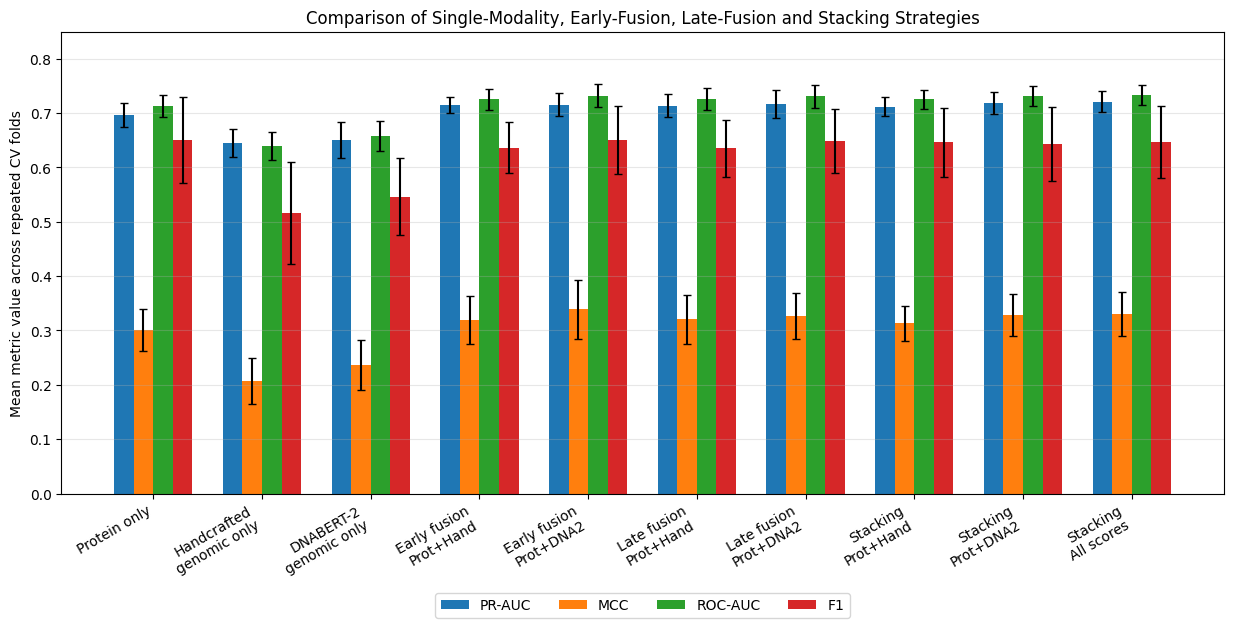

Saved: /content/drive/MyDrive/Project_Protein/model/phase22_multimodal_fusion_strategy_comparison/figures/phase22_fusion_strategy_metric_comparison.png


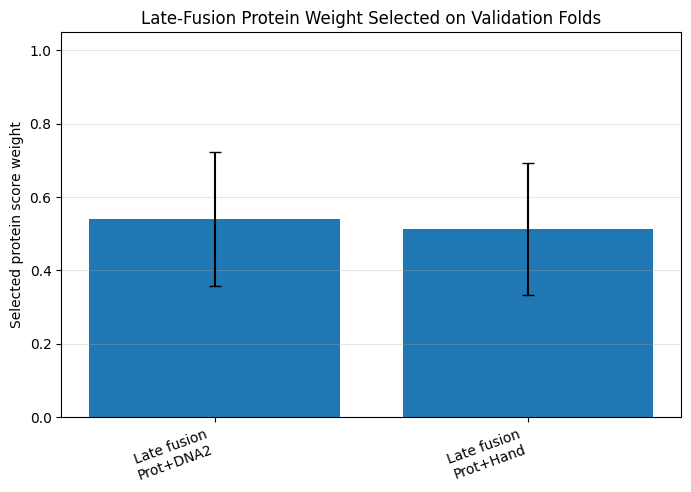

Saved: /content/drive/MyDrive/Project_Protein/model/phase22_multimodal_fusion_strategy_comparison/figures/phase22_late_fusion_selected_protein_weights.png


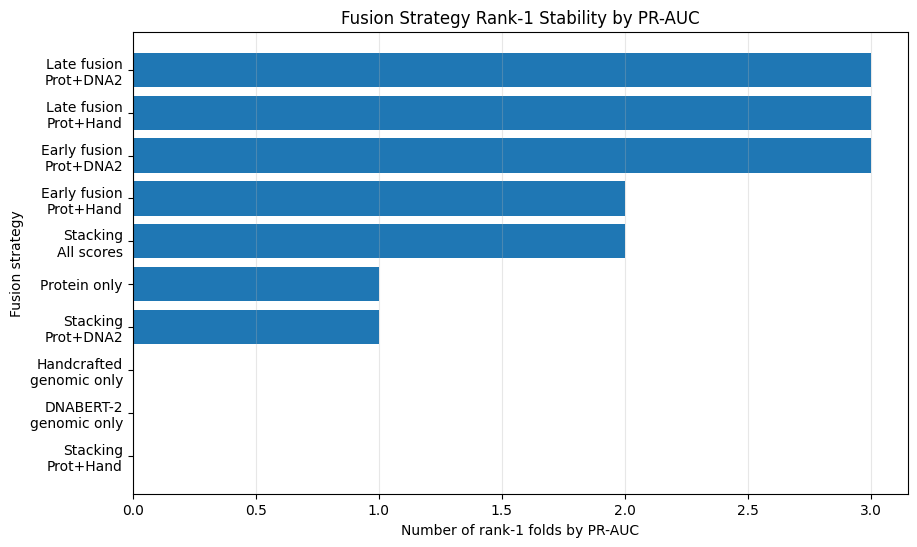

Saved: /content/drive/MyDrive/Project_Protein/model/phase22_multimodal_fusion_strategy_comparison/figures/phase22_pr_auc_rank1_stability.png


In [10]:
# ============================================================
# FIGURE 1 — MAIN METRIC COMPARISON
# ============================================================

plot_df = phase22_summary_wide_df.copy()

# Keep core strategies for readability
preferred_order = [
    "Protein_only",
    "Handcrafted_genomic_only",
    "DNABERT2_genomic_only",
    "Early_fusion_Protein_HandcraftedGenomic",
    "Early_fusion_Protein_DNABERT2Genomic",
    "Late_fusion_Protein_HandcraftedGenomic",
    "Late_fusion_Protein_DNABERT2Genomic",
    "Stacking_Protein_HandcraftedGenomic",
    "Stacking_Protein_DNABERT2Genomic",
    "Stacking_Protein_Handcrafted_DNABERT2"
]

plot_df["fusion_model"] = pd.Categorical(
    plot_df["fusion_model"],
    categories=preferred_order,
    ordered=True
)
plot_df = plot_df.sort_values("fusion_model")

label_map = {
    "Protein_only": "Protein only",
    "Handcrafted_genomic_only": "Handcrafted\ngenomic only",
    "DNABERT2_genomic_only": "DNABERT-2\ngenomic only",
    "Early_fusion_Protein_HandcraftedGenomic": "Early fusion\nProt+Hand",
    "Early_fusion_Protein_DNABERT2Genomic": "Early fusion\nProt+DNA2",
    "Late_fusion_Protein_HandcraftedGenomic": "Late fusion\nProt+Hand",
    "Late_fusion_Protein_DNABERT2Genomic": "Late fusion\nProt+DNA2",
    "Stacking_Protein_HandcraftedGenomic": "Stacking\nProt+Hand",
    "Stacking_Protein_DNABERT2Genomic": "Stacking\nProt+DNA2",
    "Stacking_Protein_Handcrafted_DNABERT2": "Stacking\nAll scores"
}

x = np.arange(len(plot_df))
width = 0.18

plt.figure(figsize=(15, 6))

for i, metric in enumerate(main_metrics):
    plt.bar(
        x + (i - 1.5) * width,
        plot_df[f"{metric}_mean"],
        yerr=plot_df[f"{metric}_sd"],
        width=width,
        capsize=3,
        label=metric.upper().replace("_", "-")
    )

plt.xticks(x, [label_map.get(m, m) for m in plot_df["fusion_model"]], rotation=30, ha="right")
plt.ylabel("Mean metric value across repeated CV folds")
plt.title("Comparison of Single-Modality, Early-Fusion, Late-Fusion and Stacking Strategies")
plt.ylim(0, 0.85)
plt.grid(axis="y", alpha=0.3)
plt.legend(ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.20))

out_path = FIGURE_DIR / "phase22_fusion_strategy_metric_comparison.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_path)


# ============================================================
# FIGURE 2 — LATE FUSION WEIGHTS
# ============================================================

if not weight_summary_df.empty:
    plot_df = weight_summary_df.copy()

    plt.figure(figsize=(8, 5))
    plt.bar(
        plot_df["fusion_model"].map(label_map).fillna(plot_df["fusion_model"]),
        plot_df["mean_weight_protein"],
        yerr=plot_df["sd_weight_protein"],
        capsize=4
    )

    plt.ylabel("Selected protein score weight")
    plt.title("Late-Fusion Protein Weight Selected on Validation Folds")
    plt.ylim(0, 1.05)
    plt.xticks(rotation=20, ha="right")
    plt.grid(axis="y", alpha=0.3)

    out_path = FIGURE_DIR / "phase22_late_fusion_selected_protein_weights.png"
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", out_path)


# ============================================================
# FIGURE 3 — RANK-1 STABILITY BY PR-AUC
# ============================================================

rank_plot_df = phase22_rank_summary_df[
    phase22_rank_summary_df["metric"] == "pr_auc"
].copy()

rank_plot_df = rank_plot_df.sort_values("n_rank1", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(
    rank_plot_df["fusion_model"].map(label_map).fillna(rank_plot_df["fusion_model"]),
    rank_plot_df["n_rank1"]
)
plt.xlabel("Number of rank-1 folds by PR-AUC")
plt.ylabel("Fusion strategy")
plt.title("Fusion Strategy Rank-1 Stability by PR-AUC")
plt.grid(axis="x", alpha=0.3)

out_path = FIGURE_DIR / "phase22_pr_auc_rank1_stability.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_path)

In [11]:
# ============================================================
# MANUSCRIPT-READY INTERPRETATION
# ============================================================

best_pr = phase22_summary_wide_df.sort_values("pr_auc_mean", ascending=False).iloc[0]
best_mcc = phase22_summary_wide_df.sort_values("mcc_mean", ascending=False).iloc[0]

# Compare best late/stacking vs early DNABERT-2
candidate_comparison = phase22_paired_df[
    phase22_paired_df["comparison"].str.contains("minus Early_fusion_Protein_DNABERT2Genomic", na=False)
].copy()

methods_text = f"""
To evaluate whether multimodal integration was limited by feature concatenation, early-fusion, late-fusion and stacking strategies were compared under repeated stratified cross-validation. Early fusion concatenated protein and genomic feature vectors prior to model training. Late fusion trained modality-specific models separately and combined protein and genomic prediction scores using validation-selected weighted averaging. Stacking used logistic regression meta-classifiers trained on modality-level validation scores. The same outer folds were used for all fusion strategies, allowing paired statistical comparison across integration methods.
""".strip()

results_text = f"""
The fusion strategy comparison showed that the strongest mean PR-AUC was achieved by {best_pr['fusion_model']} ({best_pr['pr_auc_mean']:.3f} ± {best_pr['pr_auc_sd']:.3f}), while the strongest mean MCC was achieved by {best_mcc['fusion_model']} ({best_mcc['mcc_mean']:.3f} ± {best_mcc['mcc_sd']:.3f}). Late-fusion weights were used to assess the relative contribution of protein and genomic modality scores. If the selected protein weights are consistently high, this supports the previous block-permutation finding that protein embeddings provide the dominant signal. If late fusion or stacking improves PR-AUC or MCC over early fusion, this suggests that decision-level integration can better preserve complementary genomic information than simple feature concatenation.
""".strip()

discussion_text = """
The fusion analysis directly addresses whether the limited multimodal gains were caused by the integration strategy. If late fusion or stacking provides only small improvements over early fusion, the main conclusion remains that genomic information contributes modest complementary signal but does not fundamentally change performance beyond the protein representation. Conversely, if decision-level fusion improves MCC, specificity or PR-AUC, it supports the interpretation that protein and genomic modalities contain partially complementary information whose contribution is better captured at the score level than by direct feature concatenation. In either case, the results should be interpreted as integration-strategy evidence rather than a claim of definitive model superiority.
""".strip()

wording_df = pd.DataFrame([
    {"section": "Methods - Fusion Strategy Comparison", "text": methods_text},
    {"section": "Results - Early vs Late Fusion and Stacking", "text": results_text},
    {"section": "Discussion - Multimodal Integration Interpretation", "text": discussion_text}
])

display(wording_df)

save_df(wording_df, RESULT_DIR / "phase22_manuscript_ready_wording.csv")

with open(REPORT_DIR / "phase22_manuscript_ready_wording.md", "w") as f:
    for _, row in wording_df.iterrows():
        f.write(f"## {row['section']}\n\n")
        f.write(row["text"] + "\n\n")

print("Saved manuscript wording.")

,section,text
0,Methods - Fusion Strategy Comparison,"To evaluate whether multimodal integration was limited by feature concatenation, early-fusion, late-fusion and stacking strategies were compared under repeated stratified cross-validation. Early fusion concatenated protein and genomic feature vectors prior to model training. Late fusion trained modality-specific models separately and combined protein and genomic prediction scores using validat..."
1,Results - Early vs Late Fusion and Stacking,"The fusion strategy comparison showed that the strongest mean PR-AUC was achieved by Stacking_Protein_Handcrafted_DNABERT2 (0.721 ± 0.020), while the strongest mean MCC was achieved by Early_fusion_Protein_DNABERT2Genomic (0.339 ± 0.054). Late-fusion weights were used to assess the relative contribution of protein and genomic modality scores. If the selected protein weights are consistently hi..."
2,Discussion - Multimodal Integration Interpretation,"The fusion analysis directly addresses whether the limited multimodal gains were caused by the integration strategy. If late fusion or stacking provides only small improvements over early fusion, the main conclusion remains that genomic information contributes modest complementary signal but does not fundamentally change performance beyond the protein representation. Conversely, if decision-le..."


Saved: /content/drive/MyDrive/Project_Protein/model/phase22_multimodal_fusion_strategy_comparison/results/phase22_manuscript_ready_wording.csv
Saved manuscript wording.


In [12]:
# ============================================================
# EXPORT EXCEL WORKBOOK
# ============================================================

excel_path = EXCEL_DIR / "phase22_multimodal_fusion_strategy_comparison_tables.xlsx"

tables = {
    "All_Fold_Metrics": phase22_results_df,
    "Summary_Long": phase22_summary_long_df,
    "Summary_Wide": phase22_summary_wide_df,
    "Paired_Tests": phase22_paired_df,
    "Late_Fusion_Weights": phase22_weights_df,
    "Late_Fusion_Weight_Summary": weight_summary_df,
    "Rank_By_Split": phase22_rank_df,
    "Rank_Stability": phase22_rank_summary_df,
    "Wording": wording_df
}

with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    for sheet_name, df in tables.items():
        if df is not None and not df.empty:
            df.to_excel(writer, sheet_name=sheet_name[:31], index=False)

print("Saved Excel:", excel_path)

Saved Excel: /content/drive/MyDrive/Project_Protein/model/phase22_multimodal_fusion_strategy_comparison/excel/phase22_multimodal_fusion_strategy_comparison_tables.xlsx


In [13]:
# ============================================================
# FINAL SUMMARY
# ============================================================

print("=== PHASE 22 COMPLETE ===")

print("\nFusion strategy summary:")
display(phase22_summary_wide_df)

print("\nPaired tests:")
display(phase22_paired_df)

print("\nLate fusion weight summary:")
display(weight_summary_df)

print("\nRank stability:")
display(phase22_rank_summary_df)

print("\nWording:")
display(wording_df)

print("\nFigures:")
for p in sorted(FIGURE_DIR.glob("*.png")):
    print(p)

print("\nResults:")
for p in sorted(RESULT_DIR.glob("*.csv")):
    print(p)

print("\nExcel:")
for p in sorted(EXCEL_DIR.glob("*.xlsx")):
    print(p)

print("\nReports:")
for p in sorted(REPORT_DIR.glob("*")):
    print(p)

=== PHASE 22 COMPLETE ===

Fusion strategy summary:


,fusion_model,fusion_type,pr_auc_mean,pr_auc_sd,mcc_mean,mcc_sd,roc_auc_mean,roc_auc_sd,f1_mean,f1_sd
0,Stacking_Protein_Handcrafted_DNABERT2,stacking,0.72101,0.01961,0.33056,0.04055,0.73344,0.01846,0.64623,0.06642
1,Stacking_Protein_DNABERT2Genomic,stacking,0.71929,0.02029,0.32848,0.03928,0.73168,0.01889,0.64277,0.06757
2,Late_fusion_Protein_DNABERT2Genomic,late_fusion_weighted_average,0.71738,0.02585,0.32684,0.04166,0.73070,0.02065,0.64877,0.05915
3,Early_fusion_Protein_DNABERT2Genomic,early_fusion,0.71577,0.02066,0.33877,0.05364,0.73203,0.02132,0.65015,0.06249
4,Early_fusion_Protein_HandcraftedGenomic,early_fusion,0.71449,0.01471,0.31894,0.04423,0.72548,0.01945,0.63650,0.04630
5,Late_fusion_Protein_HandcraftedGenomic,late_fusion_weighted_average,0.71312,0.02117,0.32047,0.04469,0.72541,0.02048,0.63504,0.05270
6,Stacking_Protein_HandcraftedGenomic,stacking,0.71189,0.01819,0.31314,0.03235,0.72503,0.01794,0.64592,0.06262
7,Protein_only,single_modality,0.69649,0.02286,0.30090,0.03795,0.71324,0.02071,0.65108,0.07934
8,DNABERT2_genomic_only,single_modality,0.65065,0.03329,0.23668,0.04613,0.65827,0.02759,0.54607,0.07070
9,Handcrafted_genomic_only,single_modality,0.64548,0.02586,0.20711,0.04195,0.63940,0.02545,0.51640,0.09336



Paired tests:


,comparison,model_a,model_b,metric,mean_delta,sd_delta,ci95_low,ci95_high,wins_model_a,wins_model_b,ties,wilcoxon_p,sign_test_p,n_pairs,wilcoxon_bh_fdr
0,Late_fusion_Protein_HandcraftedGenomic minus Early_fusion_Protein_HandcraftedGenomic,Late_fusion_Protein_HandcraftedGenomic,Early_fusion_Protein_HandcraftedGenomic,pr_auc,-0.00137,0.01956,-0.01141,0.00756,9,6,0,0.89038,0.60724,15,0.97797
1,Late_fusion_Protein_HandcraftedGenomic minus Early_fusion_Protein_HandcraftedGenomic,Late_fusion_Protein_HandcraftedGenomic,Early_fusion_Protein_HandcraftedGenomic,mcc,0.00153,0.06032,-0.02841,0.03017,7,8,0,0.97797,1.00000,15,0.97797
2,Late_fusion_Protein_HandcraftedGenomic minus Early_fusion_Protein_HandcraftedGenomic,Late_fusion_Protein_HandcraftedGenomic,Early_fusion_Protein_HandcraftedGenomic,roc_auc,-0.00007,0.01472,-0.00779,0.00669,8,7,0,0.90954,1.00000,15,0.97797
3,Late_fusion_Protein_HandcraftedGenomic minus Early_fusion_Protein_HandcraftedGenomic,Late_fusion_Protein_HandcraftedGenomic,Early_fusion_Protein_HandcraftedGenomic,f1,-0.00146,0.08565,-0.04383,0.03916,6,9,0,0.93408,0.60724,15,0.97797
4,Late_fusion_Protein_DNABERT2Genomic minus Early_fusion_Protein_DNABERT2Genomic,Late_fusion_Protein_DNABERT2Genomic,Early_fusion_Protein_DNABERT2Genomic,pr_auc,0.00161,0.02089,-0.00900,0.01152,9,6,0,0.67877,0.60724,15,0.76154
5,Late_fusion_Protein_DNABERT2Genomic minus Early_fusion_Protein_DNABERT2Genomic,Late_fusion_Protein_DNABERT2Genomic,Early_fusion_Protein_DNABERT2Genomic,mcc,-0.01193,0.03074,-0.02743,0.00340,6,9,0,0.20776,0.60724,15,0.76154
6,Late_fusion_Protein_DNABERT2Genomic minus Early_fusion_Protein_DNABERT2Genomic,Late_fusion_Protein_DNABERT2Genomic,Early_fusion_Protein_DNABERT2Genomic,roc_auc,-0.00134,0.01203,-0.00712,0.00459,7,8,0,0.76154,1.00000,15,0.76154
7,Late_fusion_Protein_DNABERT2Genomic minus Early_fusion_Protein_DNABERT2Genomic,Late_fusion_Protein_DNABERT2Genomic,Early_fusion_Protein_DNABERT2Genomic,f1,-0.00138,0.06850,-0.03507,0.03423,6,9,0,0.63867,0.60724,15,0.76154
8,Stacking_Protein_HandcraftedGenomic minus Early_fusion_Protein_HandcraftedGenomic,Stacking_Protein_HandcraftedGenomic,Early_fusion_Protein_HandcraftedGenomic,pr_auc,-0.00260,0.01380,-0.00873,0.00468,4,11,0,0.22931,0.11847,15,0.76154
9,Stacking_Protein_HandcraftedGenomic minus Early_fusion_Protein_HandcraftedGenomic,Stacking_Protein_HandcraftedGenomic,Early_fusion_Protein_HandcraftedGenomic,mcc,-0.00580,0.03716,-0.02504,0.01124,8,7,0,0.76154,1.00000,15,0.76154



Late fusion weight summary:


...


Rank stability:


,fusion_model,fusion_type,metric,mean_rank,sd_rank,n_rank1,n_evaluations
0,Stacking_Protein_HandcraftedGenomic,stacking,f1,4.20000,2.33605,4,15
1,Protein_only,single_modality,f1,4.33333,2.71679,3,15
2,Early_fusion_Protein_DNABERT2Genomic,early_fusion,f1,4.53333,2.89992,4,15
3,Stacking_Protein_DNABERT2Genomic,stacking,f1,4.73333,2.15362,0,15
4,Stacking_Protein_Handcrafted_DNABERT2,stacking,f1,4.73333,2.68506,2,15
5,Late_fusion_Protein_DNABERT2Genomic,late_fusion_weighted_average,f1,5.00000,2.53546,1,15
6,Early_fusion_Protein_HandcraftedGenomic,early_fusion,f1,5.06667,2.71153,1,15
7,Late_fusion_Protein_HandcraftedGenomic,late_fusion_weighted_average,f1,5.53333,2.50333,0,15
8,DNABERT2_genomic_only,single_modality,f1,8.20000,2.54109,0,15
9,Handcrafted_genomic_only,single_modality,f1,8.60000,2.19740,0,15



Wording:


,section,text
0,Methods - Fusion Strategy Comparison,"To evaluate whether multimodal integration was limited by feature concatenation, early-fusion, late-fusion and stacking strategies were compared under repeated stratified cross-validation. Early fusion concatenated protein and genomic feature vectors prior to model training. Late fusion trained modality-specific models separately and combined protein and genomic prediction scores using validat..."
1,Results - Early vs Late Fusion and Stacking,"The fusion strategy comparison showed that the strongest mean PR-AUC was achieved by Stacking_Protein_Handcrafted_DNABERT2 (0.721 ± 0.020), while the strongest mean MCC was achieved by Early_fusion_Protein_DNABERT2Genomic (0.339 ± 0.054). Late-fusion weights were used to assess the relative contribution of protein and genomic modality scores. If the selected protein weights are consistently hi..."
2,Discussion - Multimodal Integration Interpretation,"The fusion analysis directly addresses whether the limited multimodal gains were caused by the integration strategy. If late fusion or stacking provides only small improvements over early fusion, the main conclusion remains that genomic information contributes modest complementary signal but does not fundamentally change performance beyond the protein representation. Conversely, if decision-le..."



Figures:
/content/drive/MyDrive/Project_Protein/model/phase22_multimodal_fusion_strategy_comparison/figures/phase22_fusion_strategy_metric_comparison.png
/content/drive/MyDrive/Project_Protein/model/phase22_multimodal_fusion_strategy_comparison/figures/phase22_late_fusion_selected_protein_weights.png
/content/drive/MyDrive/Project_Protein/model/phase22_multimodal_fusion_strategy_comparison/figures/phase22_pr_auc_rank1_stability.png

Results:
/content/drive/MyDrive/Project_Protein/model/phase22_multimodal_fusion_strategy_comparison/results/phase22_all_fusion_strategy_fold_metrics.csv
/content/drive/MyDrive/Project_Protein/model/phase22_multimodal_fusion_strategy_comparison/results/phase22_fusion_strategy_rank_by_split.csv
/content/drive/MyDrive/Project_Protein/model/phase22_multimodal_fusion_strategy_comparison/results/phase22_fusion_strategy_rank_stability.csv
/content/drive/MyDrive/Project_Protein/model/phase22_multimodal_fusion_strategy_comparison/results/phase22_fusion_strategy_sum

In [14]:
display(phase22_summary_wide_df)

display(phase22_paired_df[[
    "comparison",
    "metric",
    "mean_delta",
    "ci95_low",
    "ci95_high",
    "wins_model_a",
    "wins_model_b",
    "wilcoxon_p",
    "wilcoxon_bh_fdr"
]])

display(weight_summary_df)

display(phase22_rank_summary_df)

,fusion_model,fusion_type,pr_auc_mean,pr_auc_sd,mcc_mean,mcc_sd,roc_auc_mean,roc_auc_sd,f1_mean,f1_sd
0,Stacking_Protein_Handcrafted_DNABERT2,stacking,0.72101,0.01961,0.33056,0.04055,0.73344,0.01846,0.64623,0.06642
1,Stacking_Protein_DNABERT2Genomic,stacking,0.71929,0.02029,0.32848,0.03928,0.73168,0.01889,0.64277,0.06757
2,Late_fusion_Protein_DNABERT2Genomic,late_fusion_weighted_average,0.71738,0.02585,0.32684,0.04166,0.73070,0.02065,0.64877,0.05915
3,Early_fusion_Protein_DNABERT2Genomic,early_fusion,0.71577,0.02066,0.33877,0.05364,0.73203,0.02132,0.65015,0.06249
4,Early_fusion_Protein_HandcraftedGenomic,early_fusion,0.71449,0.01471,0.31894,0.04423,0.72548,0.01945,0.63650,0.04630
5,Late_fusion_Protein_HandcraftedGenomic,late_fusion_weighted_average,0.71312,0.02117,0.32047,0.04469,0.72541,0.02048,0.63504,0.05270
6,Stacking_Protein_HandcraftedGenomic,stacking,0.71189,0.01819,0.31314,0.03235,0.72503,0.01794,0.64592,0.06262
7,Protein_only,single_modality,0.69649,0.02286,0.30090,0.03795,0.71324,0.02071,0.65108,0.07934
8,DNABERT2_genomic_only,single_modality,0.65065,0.03329,0.23668,0.04613,0.65827,0.02759,0.54607,0.07070
9,Handcrafted_genomic_only,single_modality,0.64548,0.02586,0.20711,0.04195,0.63940,0.02545,0.51640,0.09336


,comparison,metric,mean_delta,ci95_low,ci95_high,wins_model_a,wins_model_b,wilcoxon_p,wilcoxon_bh_fdr
0,Late_fusion_Protein_HandcraftedGenomic minus Early_fusion_Protein_HandcraftedGenomic,pr_auc,-0.00137,-0.01141,0.00756,9,6,0.89038,0.97797
1,Late_fusion_Protein_HandcraftedGenomic minus Early_fusion_Protein_HandcraftedGenomic,mcc,0.00153,-0.02841,0.03017,7,8,0.97797,0.97797
2,Late_fusion_Protein_HandcraftedGenomic minus Early_fusion_Protein_HandcraftedGenomic,roc_auc,-0.00007,-0.00779,0.00669,8,7,0.90954,0.97797
3,Late_fusion_Protein_HandcraftedGenomic minus Early_fusion_Protein_HandcraftedGenomic,f1,-0.00146,-0.04383,0.03916,6,9,0.93408,0.97797
4,Late_fusion_Protein_DNABERT2Genomic minus Early_fusion_Protein_DNABERT2Genomic,pr_auc,0.00161,-0.00900,0.01152,9,6,0.67877,0.76154
5,Late_fusion_Protein_DNABERT2Genomic minus Early_fusion_Protein_DNABERT2Genomic,mcc,-0.01193,-0.02743,0.00340,6,9,0.20776,0.76154
6,Late_fusion_Protein_DNABERT2Genomic minus Early_fusion_Protein_DNABERT2Genomic,roc_auc,-0.00134,-0.00712,0.00459,7,8,0.76154,0.76154
7,Late_fusion_Protein_DNABERT2Genomic minus Early_fusion_Protein_DNABERT2Genomic,f1,-0.00138,-0.03507,0.03423,6,9,0.63867,0.76154
8,Stacking_Protein_HandcraftedGenomic minus Early_fusion_Protein_HandcraftedGenomic,pr_auc,-0.00260,-0.00873,0.00468,4,11,0.22931,0.76154
9,Stacking_Protein_HandcraftedGenomic minus Early_fusion_Protein_HandcraftedGenomic,mcc,-0.00580,-0.02504,0.01124,8,7,0.76154,0.76154


,fusion_model,mean_weight_protein,sd_weight_protein,median_weight_protein,mean_weight_genomic,sd_weight_genomic,median_weight_genomic,n_folds
0,Late_fusion_Protein_DNABERT2Genomic,0.54000,0.18244,0.55,0.46000,0.18244,0.45,15
1,Late_fusion_Protein_HandcraftedGenomic,0.51333,0.17975,0.45,0.48667,0.17975,0.55,15


,fusion_model,fusion_type,metric,mean_rank,sd_rank,n_rank1,n_evaluations
0,Stacking_Protein_HandcraftedGenomic,stacking,f1,4.20000,2.33605,4,15
1,Protein_only,single_modality,f1,4.33333,2.71679,3,15
2,Early_fusion_Protein_DNABERT2Genomic,early_fusion,f1,4.53333,2.89992,4,15
3,Stacking_Protein_DNABERT2Genomic,stacking,f1,4.73333,2.15362,0,15
4,Stacking_Protein_Handcrafted_DNABERT2,stacking,f1,4.73333,2.68506,2,15
5,Late_fusion_Protein_DNABERT2Genomic,late_fusion_weighted_average,f1,5.00000,2.53546,1,15
6,Early_fusion_Protein_HandcraftedGenomic,early_fusion,f1,5.06667,2.71153,1,15
7,Late_fusion_Protein_HandcraftedGenomic,late_fusion_weighted_average,f1,5.53333,2.50333,0,15
8,DNABERT2_genomic_only,single_modality,f1,8.20000,2.54109,0,15
9,Handcrafted_genomic_only,single_modality,f1,8.60000,2.19740,0,15
